<a href="https://colab.research.google.com/github/Solomia0106/MY_ind/blob/main/lab_7_8_Kazymyr.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Варіант 4 - bank_b.csv

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
data = pd.read_csv('/content/drive/MyDrive/bank.csv', sep=';')

In [5]:
print("Перші 5 записів:")
print(data.head())

Перші 5 записів:
   age          job  marital  education default  balance housing loan  \
0   30   unemployed  married    primary      no     1787      no   no   
1   33     services  married  secondary      no     4789     yes  yes   
2   35   management   single   tertiary      no     1350     yes   no   
3   30   management  married   tertiary      no     1476     yes  yes   
4   59  blue-collar  married  secondary      no        0     yes   no   

    contact  day month  duration  campaign  pdays  previous poutcome   y  
0  cellular   19   oct        79         1     -1         0  unknown  no  
1  cellular   11   may       220         1    339         4  failure  no  
2  cellular   16   apr       185         1    330         1  failure  no  
3   unknown    3   jun       199         4     -1         0  unknown  no  
4   unknown    5   may       226         1     -1         0  unknown  no  


In [6]:
print("Тип даних міток класів:")
print(data['y'].dtype)

print("Унікальні мітки класів:")
print(data['y'].unique())

Тип даних міток класів:
object
Унікальні мітки класів:
['no' 'yes']


In [7]:
X = data.drop('y', axis=1)

print("Типи даних ознак:")
print(X.dtypes)

text_columns = X.select_dtypes(include=['object']).columns

print("Текстові стовпці серед ознак:")
print(text_columns)

X[text_columns] = X[text_columns].apply(
    lambda col: pd.factorize(col, sort=True)[0]
)

Типи даних ознак:
age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
dtype: object
Текстові стовпці серед ознак:
Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome'],
      dtype='object')


In [8]:
print("Кількість зразків кожного класу:")
print(data['y'].value_counts())

print("Частки класів:")
print(data['y'].value_counts(normalize=True))

Кількість зразків кожного класу:
y
no     4000
yes     521
Name: count, dtype: int64
Частки класів:
y
no     0.88476
yes    0.11524
Name: proportion, dtype: float64


In [9]:
Y = pd.get_dummies(data['y'], prefix='class')

print("Перші 5 рядків X:")
print(X.head())

print("Перші 5 рядків Y:")
print(Y.head())

Перші 5 рядків X:
   age  job  marital  education  default  balance  housing  loan  contact  \
0   30   10        1          0        0     1787        0     0        0   
1   33    7        1          1        0     4789        1     1        0   
2   35    4        2          2        0     1350        1     0        0   
3   30    4        1          2        0     1476        1     1        2   
4   59    1        1          1        0        0        1     0        2   

   day  month  duration  campaign  pdays  previous  poutcome  
0   19     10        79         1     -1         0         3  
1   11      8       220         1    339         4         0  
2   16      0       185         1    330         1         0  
3    3      6       199         4     -1         0         3  
4    5      8       226         1     -1         0         3  
Перші 5 рядків Y:
   class_no  class_yes
0      True      False
1      True      False
2      True      False
3      True      False
4      T

In [10]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.15,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(3842, 16)
(679, 16)


In [11]:
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)

X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

In [12]:
model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(16, activation='relu'),
    Dense(8, activation='relu'),
    Dense(Y_train.shape[1], activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [13]:
history = model.fit(
    X_train,
    Y_train,
    epochs=50,
    validation_split=0.15,
    batch_size=16,
    verbose=2
)

Epoch 1/50
205/205 - 3s - 13ms/step - accuracy: 0.8187 - loss: 0.4511 - val_accuracy: 0.8925 - val_loss: 0.3199
Epoch 2/50
205/205 - 1s - 4ms/step - accuracy: 0.8855 - loss: 0.3032 - val_accuracy: 0.9047 - val_loss: 0.2793
Epoch 3/50
205/205 - 1s - 6ms/step - accuracy: 0.8910 - loss: 0.2689 - val_accuracy: 0.8960 - val_loss: 0.2715
Epoch 4/50
205/205 - 1s - 5ms/step - accuracy: 0.8949 - loss: 0.2561 - val_accuracy: 0.8908 - val_loss: 0.2684
Epoch 5/50
205/205 - 1s - 6ms/step - accuracy: 0.8934 - loss: 0.2504 - val_accuracy: 0.8821 - val_loss: 0.2687
Epoch 6/50
205/205 - 1s - 4ms/step - accuracy: 0.8959 - loss: 0.2456 - val_accuracy: 0.8839 - val_loss: 0.2694
Epoch 7/50
205/205 - 1s - 3ms/step - accuracy: 0.8977 - loss: 0.2422 - val_accuracy: 0.8908 - val_loss: 0.2695
Epoch 8/50
205/205 - 1s - 2ms/step - accuracy: 0.8980 - loss: 0.2392 - val_accuracy: 0.8856 - val_loss: 0.2705
Epoch 9/50
205/205 - 0s - 2ms/step - accuracy: 0.8986 - loss: 0.2369 - val_accuracy: 0.8908 - val_loss: 0.2690


In [14]:
loss, accuracy = model.evaluate(X_test, Y_test, verbose=0)

print("Результати на тестовій множині:")
print(f"Loss = {loss:.4f}")
print(f"Accuracy = {accuracy:.4f}")

Результати на тестовій множині:
Loss = 0.2815
Accuracy = 0.8748


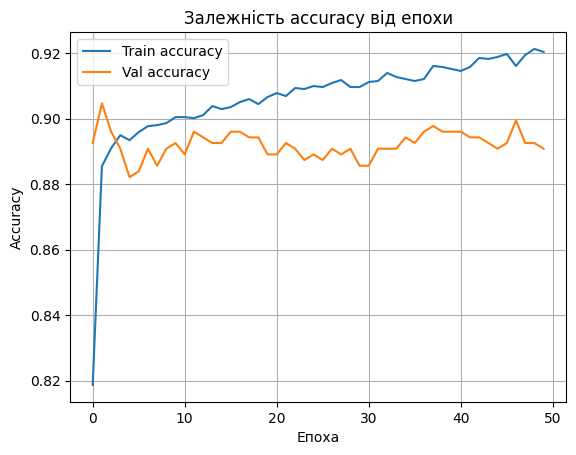

In [15]:
plt.plot(history.history['accuracy'], label='Train accuracy')
plt.plot(history.history['val_accuracy'], label='Val accuracy')
plt.title('Залежність accuracy від епохи')
plt.xlabel('Епоха')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [16]:
sample = X_test.iloc[0:1]
prediction = model.predict(sample, verbose=0)

score = np.max(prediction)
predicted_class_index = np.argmax(prediction)
true_class_index = np.argmax(Y_test.iloc[0:1].values)

class_names = list(Y.columns)
predicted_class_name = class_names[predicted_class_index]
true_class_name = class_names[true_class_index]

print("Результат для одного зразка:")
print(f"Передбачено клас {predicted_class_name} з достовірністю {score * 100:.2f}%")
print(f"Правильний клас: {true_class_name}")

Результат для одного зразка:
Передбачено клас class_no з достовірністю 99.95%
Правильний клас: class_no


In [17]:
model.save('bank_model.h5')
print("Модель збережено у файл bank_model.h5")

Модель збережено у файл bank_model.h5


ЛАБОРАТОРНА 8


In [18]:
loss, acc = model.evaluate(X_test, Y_test, verbose=0)

print("Базова точність:", acc)

Базова точність: 0.8748158812522888


In [19]:
from tensorflow.keras.layers import Dropout

model_dropout = Sequential()

model_dropout.add(Dense(16, input_dim=X_train.shape[1], activation="relu"))
model_dropout.add(Dropout(0.2))
model_dropout.add(Dense(Y_train.shape[1], activation="softmax"))

model_dropout.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_dropout = model_dropout.fit(
    X_train,
    Y_train,
    epochs=50,
    validation_split=0.15
)

loss_d, acc_d = model_dropout.evaluate(X_test, Y_test)

print("Точність з Dropout:", acc_d)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


103/103 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7688 - loss: 0.5348 - val_accuracy: 0.8821 - val_loss: 0.3763
Epoch 2/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8738 - loss: 0.3725 - val_accuracy: 0.8908 - val_loss: 0.3082
Epoch 3/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8787 - loss: 0.3239 - val_accuracy: 0.8925 - val_loss: 0.2867
Epoch 4/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8787 - loss: 0.3027 - val_accuracy: 0.8943 - val_loss: 0.2798
Epoch 5/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8824 - loss: 0.2859 - val_accuracy: 0.8908 - val_loss: 0.2761
Epoch 6/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8861 - loss: 0.2795 - val_accuracy: 0.8873 - val_loss: 0.2734
Epoch 7/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8870 - loss: 0.2725 - val_accuracy: 0.8891 - val_loss: 0.2720
Epoch 8/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8931 - loss: 0.2712 - val_accuracy: 0.8908 - val_

In [20]:
from tensorflow.keras.callbacks import EarlyStopping

early = EarlyStopping(
    monitor='val_loss',
    patience=5
)

model_early = Sequential()

model_early.add(Dense(16, input_dim=X_train.shape[1], activation="relu"))
model_early.add(Dense(Y_train.shape[1], activation="softmax"))

model_early.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_early = model_early.fit(
    X_train,
    Y_train,
    epochs=50,
    validation_split=0.15,
    callbacks=[early]
)

loss_e, acc_e = model_early.evaluate(X_test, Y_test)

print("Точність з EarlyStopping:", acc_e)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


103/103 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8260 - loss: 0.4649 - val_accuracy: 0.8804 - val_loss: 0.3584
Epoch 2/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8802 - loss: 0.3305 - val_accuracy: 0.8977 - val_loss: 0.3030
Epoch 3/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8851 - loss: 0.2924 - val_accuracy: 0.8925 - val_loss: 0.2840
Epoch 4/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8904 - loss: 0.2745 - val_accuracy: 0.8943 - val_loss: 0.2762
Epoch 5/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8919 - loss: 0.2652 - val_accuracy: 0.8943 - val_loss: 0.2740
Epoch 6/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8931 - loss: 0.2594 - val_accuracy: 0.8925 - val_loss: 0.2732
Epoch 7/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8965 - loss: 0.2554 - val_accuracy: 0.8925 - val_loss: 0.2735
Epoch 8/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8956 - loss: 0.2524 - val_accuracy: 0.8943 - va

In [21]:
model_simple = Sequential()

model_simple.add(Dense(6, input_dim=X_train.shape[1], activation="relu"))
model_simple.add(Dense(Y_train.shape[1], activation="softmax"))

model_simple.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_simple = model_simple.fit(
    X_train,
    Y_train,
    epochs=50,
    validation_split=0.15
)

loss_s, acc_s = model_simple.evaluate(X_test, Y_test)

print("Точність спрощеної моделі:", acc_s)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


103/103 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.2625 - loss: 1.5971 - val_accuracy: 0.3674 - val_loss: 1.1508
Epoch 2/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4753 - loss: 0.9327 - val_accuracy: 0.6066 - val_loss: 0.6979
Epoch 3/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7185 - loss: 0.5968 - val_accuracy: 0.8163 - val_loss: 0.4889
Epoch 4/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8484 - loss: 0.4470 - val_accuracy: 0.8839 - val_loss: 0.3992
Epoch 5/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8818 - loss: 0.3808 - val_accuracy: 0.8821 - val_loss: 0.3548
Epoch 6/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8851 - loss: 0.3443 - val_accuracy: 0.8839 - val_loss: 0.3280
Epoch 7/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8861 - loss: 0.3230 - val_accuracy: 0.8821 - val_loss: 0.3135
Epoch 8/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8867 - loss: 0.3074 - val_accuracy: 0.8873 - val_

In [22]:
from tensorflow.keras.layers import BatchNormalization

model_bn = Sequential()

model_bn.add(Dense(16, input_dim=X_train.shape[1], activation="relu"))
model_bn.add(BatchNormalization())
model_bn.add(Dense(Y_train.shape[1], activation="softmax"))

model_bn.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_bn = model_bn.fit(
    X_train,
    Y_train,
    epochs=50,
    validation_split=0.15
)

loss_bn, acc_bn = model_bn.evaluate(X_test, Y_test)

print("Точність з BatchNormalization:", acc_bn)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


103/103 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6499 - loss: 0.7045 - val_accuracy: 0.7366 - val_loss: 0.5723
Epoch 2/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8242 - loss: 0.4278 - val_accuracy: 0.8579 - val_loss: 0.3809
Epoch 3/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8763 - loss: 0.3309 - val_accuracy: 0.8769 - val_loss: 0.3147
Epoch 4/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8888 - loss: 0.2923 - val_accuracy: 0.8804 - val_loss: 0.2976
Epoch 5/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8904 - loss: 0.2754 - val_accuracy: 0.8735 - val_loss: 0.2948
Epoch 6/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8900 - loss: 0.2678 - val_accuracy: 0.8769 - val_loss: 0.2917
Epoch 7/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8928 - loss: 0.2636 - val_accuracy: 0.8839 - val_loss: 0.2875
Epoch 8/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8940 - loss: 0.2619 - val_accuracy: 0.8856 - val_

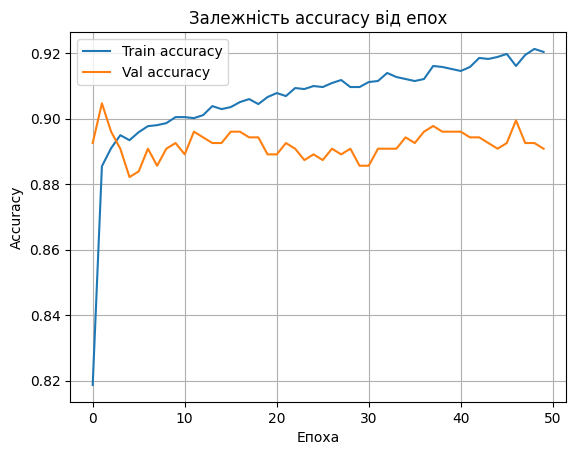

In [23]:
plt.plot(history.history['accuracy'], label='Train accuracy')
plt.plot(history.history['val_accuracy'], label='Val accuracy')

plt.title('Залежність accuracy від епох')
plt.xlabel('Епоха')
plt.ylabel('Accuracy')

plt.legend()
plt.grid(True)

plt.show()